# Task 3: Charger Utilisation & Efficiency Analysis

## Objective

Analyse EV charger utilisation, idle time, and peak-load patterns to identify bottlenecks, compare charger performance, and support infrastructure capacity optimisation.

## Deliverables

- Utilisation heatmaps per station/charger
- Idle-time analysis
- Peak-load charts
- Ranking of high/low-performing chargers
- Capacity optimisation recommendations

## Approach

The analysis will use EV charging session data to measure charger usage and identify periods of high and low utilisation. Charger-level and station-level performance will be compared to identify potential bottlenecks and opportunities for improving infrastructure efficiency.

## Key Analysis Areas

1. Charger utilisation analysis
2. Idle-time analysis
3. Peak-load analysis
4. Charger performance ranking
5. Capacity optimisation recommendations

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "ev_charging_dataset.xlsx"

sessions = pd.read_excel(
    file_path,
    sheet_name="sessions"
)

sessions["start_timestamp"] = pd.to_datetime(
    sessions["start_timestamp"]
)

sessions["end_timestamp"] = pd.to_datetime(
    sessions["end_timestamp"]
)

print("Dataset shape:", sessions.shape)

print("\nRelevant columns:")
print(
    sessions[
        [
            "station_id",
            "charger_id",
            "charger_type",
            "start_timestamp",
            "end_timestamp",
            "session_duration_minutes",
            "energy_kwh"
        ]
    ].head()
)

print("\nMissing values:")
print(
    sessions[
        [
            "station_id",
            "charger_id",
            "start_timestamp",
            "end_timestamp",
            "session_duration_minutes",
            "energy_kwh"
        ]
    ].isnull().sum()
)

Dataset shape: (294024, 15)

Relevant columns:
  station_id     charger_id charger_type     start_timestamp  \
0    STN_001  STN_001_CH_02     DC_150kW 2022-01-01 08:30:00   
1    STN_001  STN_001_CH_02     DC_150kW 2022-01-01 09:20:00   
2    STN_001  STN_001_CH_04      DC_50kW 2022-01-01 09:00:00   
3    STN_001  STN_001_CH_01      DC_50kW 2022-01-01 23:20:00   
4    STN_001  STN_001_CH_01      DC_50kW 2022-01-01 16:10:00   

        end_timestamp  session_duration_minutes  energy_kwh  
0 2022-01-01 08:56:00                        26        56.9  
1 2022-01-01 09:41:00                        21        40.7  
2 2022-01-01 09:48:00                        48        30.9  
3 2022-01-02 00:01:00                        41        28.4  
4 2022-01-01 17:00:00                        50        31.7  

Missing values:
station_id                  0
charger_id                  0
start_timestamp             0
end_timestamp               0
session_duration_minutes    0
energy_kwh                  0

In [4]:
# Calculate charger utilisation

sessions["session_hours"] = (
    sessions["session_duration_minutes"] / 60
)

charger_utilisation = (
    sessions
    .groupby(["station_id", "charger_id", "charger_type"])
    .agg(
        total_sessions=("session_duration_minutes", "count"),
        total_charging_hours=("session_hours", "sum"),
        total_energy_kwh=("energy_kwh", "sum")
    )
    .reset_index()
)

# Calculate the total available hours during the dataset period
dataset_days = (
    sessions["start_timestamp"].max()
    - sessions["start_timestamp"].min()
).days + 1

available_hours = dataset_days * 24

charger_utilisation["utilisation_pct"] = (
    charger_utilisation["total_charging_hours"]
    / available_hours
) * 100

print("Charger Utilisation Analysis")
print("-" * 40)

display(
    charger_utilisation.sort_values(
        "utilisation_pct",
        ascending=False
    ).head(10)
)

Charger Utilisation Analysis
----------------------------------------


,station_id,charger_id,charger_type,total_sessions,total_charging_hours,total_energy_kwh,utilisation_pct
3,STN_001,STN_001_CH_04,DC_50kW,3848,3172.466667,126957.9,12.060777
35,STN_007,STN_007_CH_02,DC_50kW,3839,3157.250000,126245.6,12.002927
37,STN_007,STN_007_CH_04,DC_50kW,3817,3150.850000,126216.4,11.978596
0,STN_001,STN_001_CH_01,DC_50kW,3731,3080.983333,123295.5,11.712984
36,STN_007,STN_007_CH_03,DC_50kW,3697,3047.150000,121755.3,11.584360
33,STN_006,STN_006_CH_04,DC_50kW,3662,3018.250000,120353.7,11.474491
9,STN_003,STN_003_CH_01,DC_50kW,3101,2552.550000,102133.1,9.704037
4,STN_002,STN_002_CH_01,DC_50kW,3084,2542.650000,101707.9,9.666401
13,STN_003,STN_003_CH_05,DC_50kW,3081,2536.850000,101451.6,9.644351
38,STN_008,STN_008_CH_01,DC_50kW,3003,2478.800000,99249.3,9.423662


In [5]:
# Calculate charger utilisation

sessions["session_hours"] = (
    sessions["session_duration_minutes"] / 60
)

charger_utilisation = (
    sessions
    .groupby(["station_id", "charger_id", "charger_type"])
    .agg(
        total_sessions=("session_duration_minutes", "count"),
        total_charging_hours=("session_hours", "sum"),
        total_energy_kwh=("energy_kwh", "sum")
    )
    .reset_index()
)

# Calculate the total available hours during the dataset period
dataset_days = (
    sessions["start_timestamp"].max()
    - sessions["start_timestamp"].min()
).days + 1

available_hours = dataset_days * 24

charger_utilisation["utilisation_pct"] = (
    charger_utilisation["total_charging_hours"]
    / available_hours
) * 100

print("Charger Utilisation Analysis")
print("-" * 40)

display(
    charger_utilisation.sort_values(
        "utilisation_pct",
        ascending=False
    ).head(10)
)

Charger Utilisation Analysis
----------------------------------------


,station_id,charger_id,charger_type,total_sessions,total_charging_hours,total_energy_kwh,utilisation_pct
3,STN_001,STN_001_CH_04,DC_50kW,3848,3172.466667,126957.9,12.060777
35,STN_007,STN_007_CH_02,DC_50kW,3839,3157.250000,126245.6,12.002927
37,STN_007,STN_007_CH_04,DC_50kW,3817,3150.850000,126216.4,11.978596
0,STN_001,STN_001_CH_01,DC_50kW,3731,3080.983333,123295.5,11.712984
36,STN_007,STN_007_CH_03,DC_50kW,3697,3047.150000,121755.3,11.584360
33,STN_006,STN_006_CH_04,DC_50kW,3662,3018.250000,120353.7,11.474491
9,STN_003,STN_003_CH_01,DC_50kW,3101,2552.550000,102133.1,9.704037
4,STN_002,STN_002_CH_01,DC_50kW,3084,2542.650000,101707.9,9.666401
13,STN_003,STN_003_CH_05,DC_50kW,3081,2536.850000,101451.6,9.644351
38,STN_008,STN_008_CH_01,DC_50kW,3003,2478.800000,99249.3,9.423662


In [6]:
# Calculate charger idle time

charger_utilisation["available_hours"] = available_hours

charger_utilisation["idle_hours"] = (
    charger_utilisation["available_hours"]
    - charger_utilisation["total_charging_hours"]
)

charger_utilisation["idle_pct"] = (
    charger_utilisation["idle_hours"]
    / charger_utilisation["available_hours"]
) * 100

print("Charger Idle-Time Analysis")
print("-" * 40)

display(
    charger_utilisation[
        [
            "station_id",
            "charger_id",
            "charger_type",
            "total_charging_hours",
            "idle_hours",
            "idle_pct"
        ]
    ]
    .sort_values("idle_pct", ascending=False)
    .head(10)
)

Charger Idle-Time Analysis
----------------------------------------


,station_id,charger_id,charger_type,total_charging_hours,idle_hours,idle_pct
147,STN_025,STN_025_CH_02,DC_300kW,192.650000,26111.350000,99.267602
165,STN_027,STN_027_CH_04,DC_300kW,193.150000,26110.850000,99.265701
131,STN_023,STN_023_CH_01,DC_300kW,201.716667,26102.283333,99.233133
148,STN_025,STN_025_CH_03,DC_300kW,204.700000,26099.300000,99.221791
167,STN_027,STN_027_CH_06,DC_300kW,213.283333,26090.716667,99.189160
109,STN_019,STN_019_CH_04,DC_300kW,235.566667,26068.433333,99.104445
123,STN_021,STN_021_CH_05,DC_150kW,238.766667,26065.233333,99.092280
160,STN_026,STN_026_CH_07,DC_150kW,240.700000,26063.300000,99.084930
151,STN_025,STN_025_CH_06,DC_150kW,242.800000,26061.200000,99.076946
120,STN_021,STN_021_CH_02,DC_150kW,243.600000,26060.400000,99.073905


In [7]:
# Analyse peak charging load by hour

sessions["hour"] = sessions["start_timestamp"].dt.hour

hourly_load = (
    sessions
    .groupby("hour")
    .agg(
        total_energy_kwh=("energy_kwh", "sum"),
        total_sessions=("session_id", "count")
    )
    .reset_index()
)

print("Peak-Load Analysis")
print("-" * 40)

display(
    hourly_load.sort_values(
        "total_energy_kwh",
        ascending=False
    ).head(10)
)

Peak-Load Analysis
----------------------------------------


,hour,total_energy_kwh,total_sessions
10,10,1134524.0,24214
14,14,1131890.0,24120
13,13,1131742.8,24123
11,11,1129683.7,24048
12,12,1123218.3,23945
9,9,1004475.5,21370
15,15,1004073.7,21251
16,16,881564.0,18750
8,8,750802.3,15967
17,17,748783.4,15992


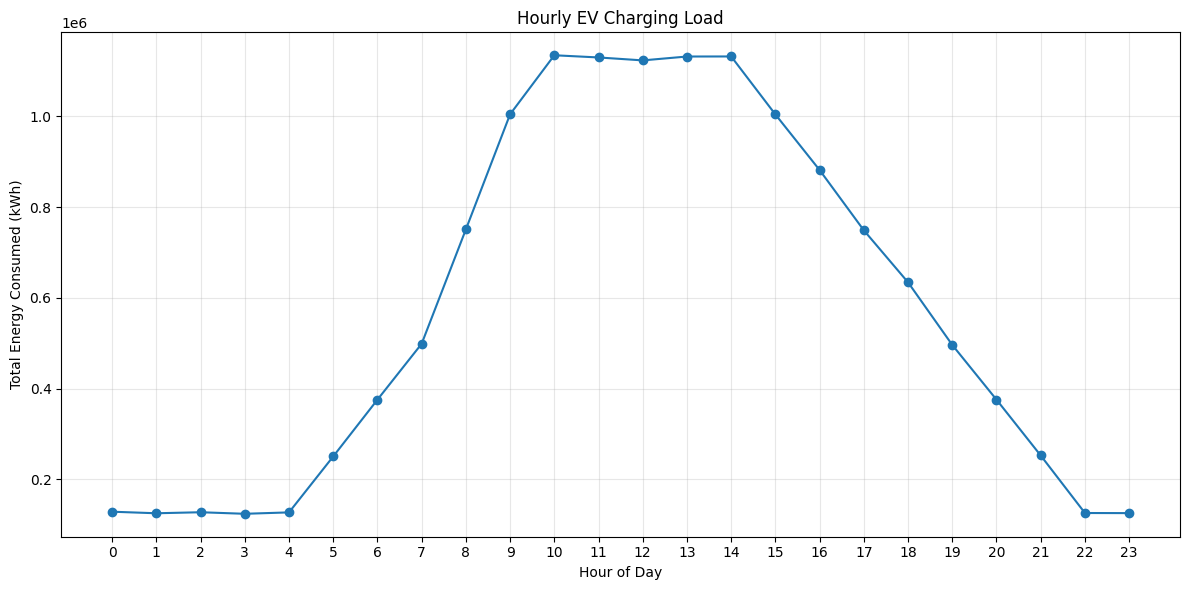

In [8]:
# Visualise hourly peak charging load

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_load["hour"],
    hourly_load["total_energy_kwh"],
    marker="o"
)

plt.title("Hourly EV Charging Load")
plt.xlabel("Hour of Day")
plt.ylabel("Total Energy Consumed (kWh)")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Rank chargers by utilisation

charger_ranking = (
    charger_utilisation
    .sort_values("utilisation_pct", ascending=False)
    .reset_index(drop=True)
)

charger_ranking["performance_rank"] = (
    charger_ranking.index + 1
)

print("Charger Performance Ranking")
print("-" * 40)

display(
    charger_ranking[
        [
            "performance_rank",
            "station_id",
            "charger_id",
            "charger_type",
            "total_sessions",
            "total_energy_kwh",
            "utilisation_pct"
        ]
    ].head(10)
)

print("\nLowest Utilisation Chargers")
print("-" * 40)

display(
    charger_ranking[
        [
            "performance_rank",
            "station_id",
            "charger_id",
            "charger_type",
            "total_sessions",
            "total_energy_kwh",
            "utilisation_pct"
        ]
    ].tail(10)
)

Charger Performance Ranking
----------------------------------------


,performance_rank,station_id,charger_id,charger_type,total_sessions,total_energy_kwh,utilisation_pct
0,1,STN_001,STN_001_CH_04,DC_50kW,3848,126957.9,12.060777
1,2,STN_007,STN_007_CH_02,DC_50kW,3839,126245.6,12.002927
2,3,STN_007,STN_007_CH_04,DC_50kW,3817,126216.4,11.978596
3,4,STN_001,STN_001_CH_01,DC_50kW,3731,123295.5,11.712984
4,5,STN_007,STN_007_CH_03,DC_50kW,3697,121755.3,11.584360
5,6,STN_006,STN_006_CH_04,DC_50kW,3662,120353.7,11.474491
6,7,STN_003,STN_003_CH_01,DC_50kW,3101,102133.1,9.704037
7,8,STN_002,STN_002_CH_01,DC_50kW,3084,101707.9,9.666401
8,9,STN_003,STN_003_CH_05,DC_50kW,3081,101451.6,9.644351
9,10,STN_008,STN_008_CH_01,DC_50kW,3003,99249.3,9.423662



Lowest Utilisation Chargers
----------------------------------------


,performance_rank,station_id,charger_id,charger_type,total_sessions,total_energy_kwh,utilisation_pct
189,190,STN_021,STN_021_CH_02,DC_150kW,594,29080.7,0.926095
190,191,STN_025,STN_025_CH_06,DC_150kW,596,29034.1,0.923054
191,192,STN_026,STN_026_CH_07,DC_150kW,590,28945.9,0.915070
192,193,STN_021,STN_021_CH_05,DC_150kW,586,28587.7,0.907720
193,194,STN_019,STN_019_CH_04,DC_300kW,726,54771.6,0.895555
194,195,STN_027,STN_027_CH_06,DC_300kW,658,49630.2,0.810840
195,196,STN_025,STN_025_CH_03,DC_300kW,632,47575.4,0.778209
196,197,STN_023,STN_023_CH_01,DC_300kW,620,46923.8,0.766867
197,198,STN_027,STN_027_CH_04,DC_300kW,593,44932.8,0.734299
198,199,STN_025,STN_025_CH_02,DC_300kW,598,44921.5,0.732398


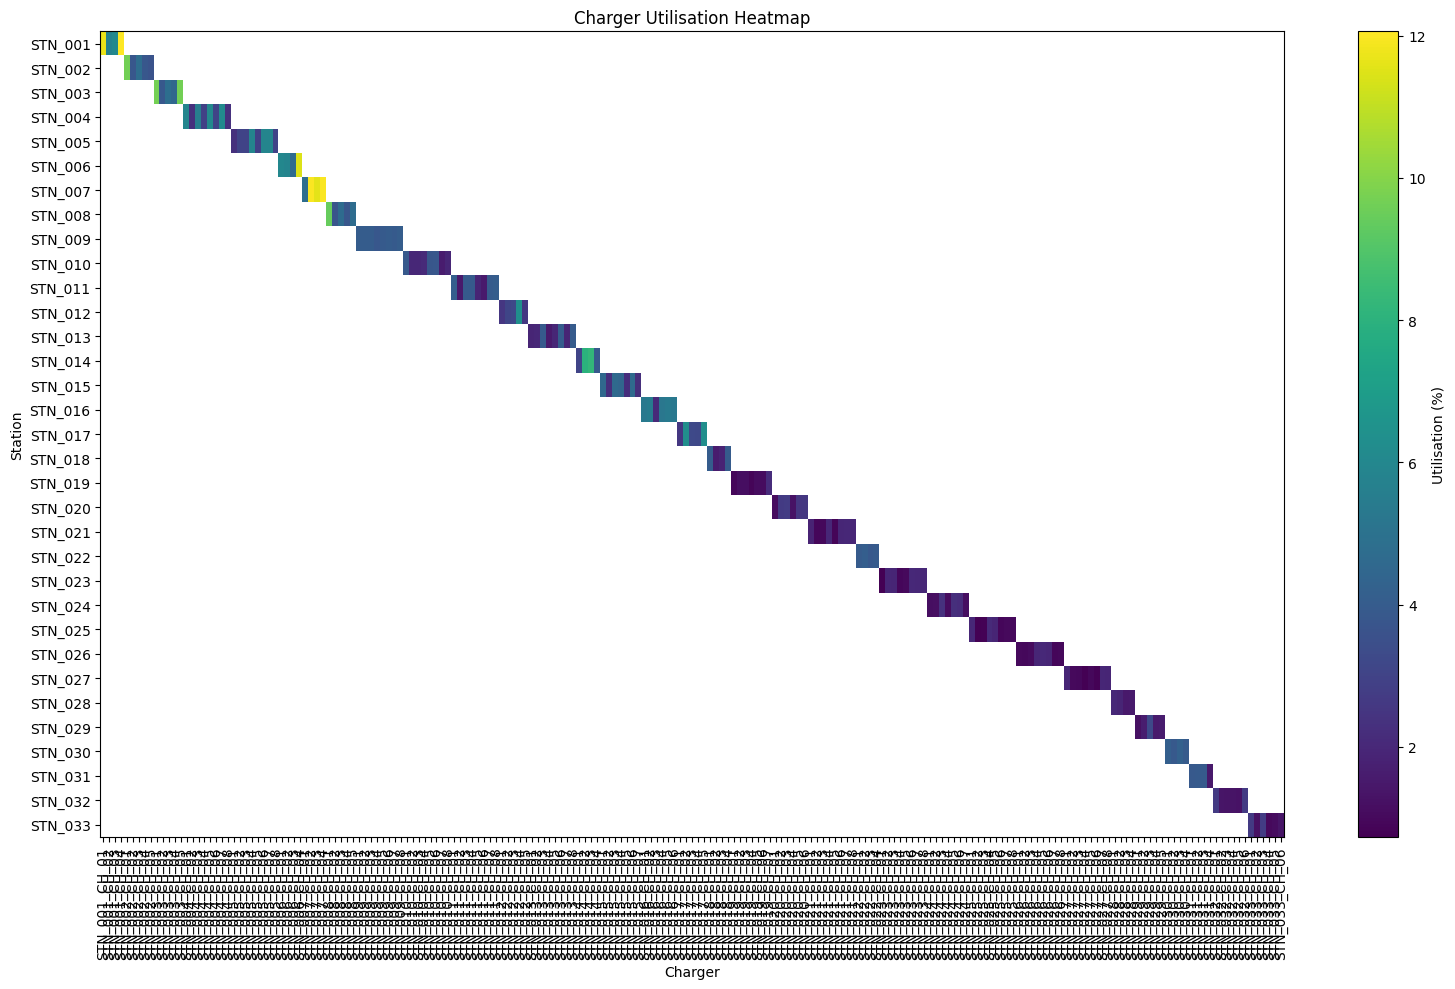

In [10]:
# Create station-wise charger utilisation heatmap

utilisation_heatmap = charger_utilisation.pivot_table(
    index="station_id",
    columns="charger_id",
    values="utilisation_pct"
)

plt.figure(figsize=(16, 10))

plt.imshow(
    utilisation_heatmap,
    aspect="auto"
)

plt.colorbar(label="Utilisation (%)")

plt.title("Charger Utilisation Heatmap")
plt.xlabel("Charger")
plt.ylabel("Station")

plt.xticks(
    range(len(utilisation_heatmap.columns)),
    utilisation_heatmap.columns,
    rotation=90
)

plt.yticks(
    range(len(utilisation_heatmap.index)),
    utilisation_heatmap.index
)

plt.tight_layout()
plt.show()

In [11]:
# Generate station-level capacity optimisation analysis

station_capacity = (
    charger_utilisation
    .groupby("station_id")
    .agg(
        total_chargers=("charger_id", "count"),
        total_sessions=("total_sessions", "sum"),
        total_energy_kwh=("total_energy_kwh", "sum"),
        average_utilisation_pct=("utilisation_pct", "mean")
    )
    .reset_index()
)

station_capacity = station_capacity.sort_values(
    "average_utilisation_pct",
    ascending=False
)

print("Station Capacity Optimisation Analysis")
print("-" * 45)

display(station_capacity)

Station Capacity Optimisation Analysis
---------------------------------------------


,station_id,total_chargers,total_sessions,total_energy_kwh,average_utilisation_pct
6,STN_007,4,15218,666315.7,10.085301
0,STN_001,4,15162,620951.6,8.880620
5,STN_006,4,15045,778478.1,6.986707
2,STN_003,5,15321,733802.6,6.512292
13,STN_014,4,10161,480807.6,5.785860
7,STN_008,5,15154,854549.0,5.268172
1,STN_002,5,15276,940999.0,5.137381
15,STN_016,6,10170,406923.6,4.783704
16,STN_017,5,10289,494681.8,4.339479
3,STN_004,8,15121,720723.5,4.280868


## Capacity Optimisation Recommendations

The charger utilisation and station-level analysis provides insights into infrastructure usage and capacity distribution.

### Key Findings

- STN_007 has the highest average charger utilisation at approximately 10.09%, indicating relatively higher demand compared with the other stations.
- STN_001 has the second-highest average utilisation at approximately 8.88%.
- Several stations, including STN_025, STN_027, and STN_019, have relatively low average utilisation despite having multiple chargers.
- The hourly analysis shows that charging activity is highest between approximately 9 AM and 4 PM, with the highest observed energy demand at 10 AM.
- The utilisation ranking shows significant variation between individual chargers, indicating that demand is not evenly distributed across the infrastructure.

### Recommendations

1. **Monitor high-utilisation stations:** Stations such as STN_007 and STN_001 should be monitored during peak periods to identify possible congestion or capacity constraints.

2. **Improve utilisation of low-demand chargers:** Chargers with consistently low utilisation can be reviewed before adding additional capacity at the same locations.

3. **Plan capacity around peak hours:** Infrastructure planning should consider the high-demand period between 9 AM and 4 PM.

4. **Redistribute charging demand where possible:** If operationally feasible, users can be encouraged to use underutilised chargers or nearby stations through pricing or availability information.

5. **Use charger-level performance monitoring:** Individual charger utilisation should be tracked regularly to identify bottlenecks and inefficient capacity allocation.

### Conclusion

The analysis demonstrates that charger utilisation varies considerably across stations and individual chargers. Peak charging activity is concentrated during daytime hours, while several chargers remain substantially underutilised.

These findings can support data-driven infrastructure planning by identifying locations that require closer monitoring and areas where additional capacity may not currently be necessary.

**Note:** Utilisation and idle-time percentages are based on total session charging time relative to the overall dataset period. They represent a session-time-based utilisation measure and should be interpreted as an analytical proxy rather than direct measurement of physical charger availability.